# Airbnb Price Prediction

## DS605: Fundamentals of Machine Learning
### Lab Assignment - 4

### Objective
The objective of this project is to develop an end-to-end machine learning workflow for predicting the nightly price of Airbnb listings in New York City.

The project includes:
- Data analysis and preprocessing
- Exploratory data analysis
- Feature engineering and feature selection
- Training and comparison of regression models
- Hyperparameter tuning
- Model evaluation
- Saving the final machine learning pipeline
- Building a Streamlit web application for price prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("data/AB_NYC_2019.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Task 1 - Data Analysis and Preparation

### 1.1 Understanding the Dataset

Before preprocessing the data, we first examine the structure of the dataset, column names, data types, summary statistics, and missing values. This helps us understand the available features and identify the preprocessing steps required.

In [3]:
# Display basic information about the dataset

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 48895
Number of Columns: 16

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude   

### 1.2 Summary Statistics

Summary statistics are used to understand the distribution, central tendency, and spread of the numerical features in the dataset.

In [4]:
# Statistical summary of numerical columns
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### 1.3 Checking Missing Values

Missing values can affect the performance of machine learning models. Therefore, we check the number and percentage of missing values in each column before deciding how to handle them.

In [5]:
# Check missing values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

missing_values

,Missing Values,Percentage (%)
name,16,0.032723
host_name,21,0.042949
last_review,10052,20.558339
reviews_per_month,10052,20.558339


### 1.4 Handling Missing Values

The dataset contains missing values in `name`, `host_name`, `last_review`, and `reviews_per_month`.

- `name` and `host_name` are not useful for predicting Airbnb prices, so these columns will be removed.
- `last_review` contains a large number of missing values and is not directly required for the prediction model, so it will also be removed.
- Missing values in `reviews_per_month` are replaced with 0. A missing value in this column generally corresponds to listings that have not received reviews.

The identifier columns `id` and `host_id` are also removed because they uniquely identify listings or hosts and do not provide meaningful generalizable information for price prediction.

In [6]:
# Remove unnecessary columns

df = df.drop(columns=[
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
])

# Fill missing reviews_per_month values with 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print("Dataset Shape After Removing Columns:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset Shape After Removing Columns: (48895, 11)

Missing Values After Cleaning:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


### 1.5 Checking Duplicate Records

Duplicate records may introduce bias into the analysis and model training. Therefore, the dataset is checked for duplicate rows and any duplicates found are removed.

In [7]:
# Check for duplicate rows

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

# Remove duplicates if present
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Number of Duplicate Rows: 0
Dataset Shape After Removing Duplicates: (48895, 11)


### 1.6 Analysis of the Target Variable - Price

The target variable for this machine learning problem is `price`, which represents the nightly price of an Airbnb listing.

The distribution of price is examined to identify unusual values and potential outliers. Extreme price values can significantly affect regression models and therefore need to be handled appropriately.

Price Statistics:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Number of listings with price = 0:
11

Minimum Price: 0
Maximum Price: 10000


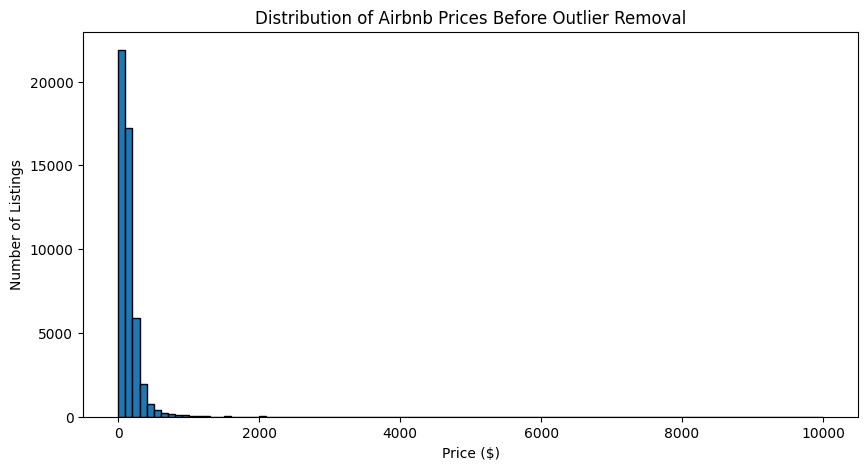

In [8]:
# Examine price statistics

print("Price Statistics:")
print(df["price"].describe())

print("\nNumber of listings with price = 0:")
print((df["price"] == 0).sum())

print("\nMinimum Price:", df["price"].min())
print("Maximum Price:", df["price"].max())

# Visualize the original price distribution

plt.figure(figsize=(10, 5))

plt.hist(df["price"], bins=100, edgecolor="black")

plt.title("Distribution of Airbnb Prices Before Outlier Removal")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

### 1.7 Handling Price Outliers

Airbnb prices contain extreme values that can negatively affect regression model performance. The Interquartile Range (IQR) method is used to identify and remove extreme price outliers.

The IQR is calculated as:

**IQR = Q3 - Q1**

The lower and upper bounds are then calculated as:

**Lower Bound = Q1 - 1.5 × IQR**

**Upper Bound = Q3 + 1.5 × IQR**

Listings with prices outside these bounds are treated as outliers. Additionally, listings with a price of 0 are removed because a zero nightly price is not meaningful for this prediction problem.

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower Bound: -90.0
Upper Bound: 334.0

Dataset Shape After Price Outlier Removal: (45912, 11)

Updated Price Statistics:
count    45912.000000
mean       119.999063
std         68.133003
min         10.000000
25%         65.000000
50%        100.000000
75%        159.000000
max        334.000000
Name: price, dtype: float64


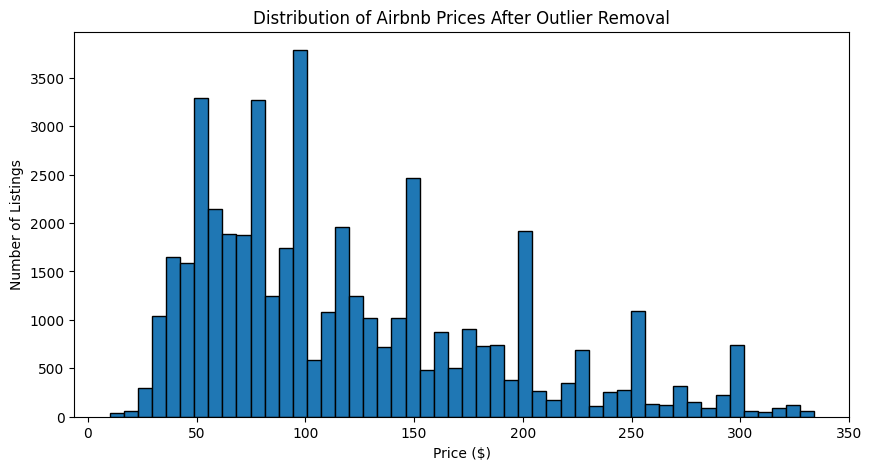

In [9]:
# Remove listings with zero price
df = df[df["price"] > 0]

# Calculate IQR for price
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Remove price outliers
df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

print("\nDataset Shape After Price Outlier Removal:", df.shape)

print("\nUpdated Price Statistics:")
print(df["price"].describe())


# Price distribution after outlier removal

plt.figure(figsize=(10, 5))

plt.hist(df["price"], bins=50, edgecolor="black")

plt.title("Distribution of Airbnb Prices After Outlier Removal")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

### 1.8 Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the relationships between different Airbnb listing characteristics and the target variable `price`.

The analysis focuses on:
- Distribution of listings across neighbourhood groups
- Average price across neighbourhood groups
- Average price across room types
- Relationship between numerical features and price
- Correlation between numerical variables
- Geographical distribution of Airbnb listings

#### 1.8.1 Distribution of Listings by Neighbourhood Group

The number of Airbnb listings in each neighbourhood group is examined to understand how listings are distributed across New York City.

neighbourhood_group
Manhattan        19505
Brooklyn         19406
Queens            5567
Bronx             1069
Staten Island      365
Name: count, dtype: int64


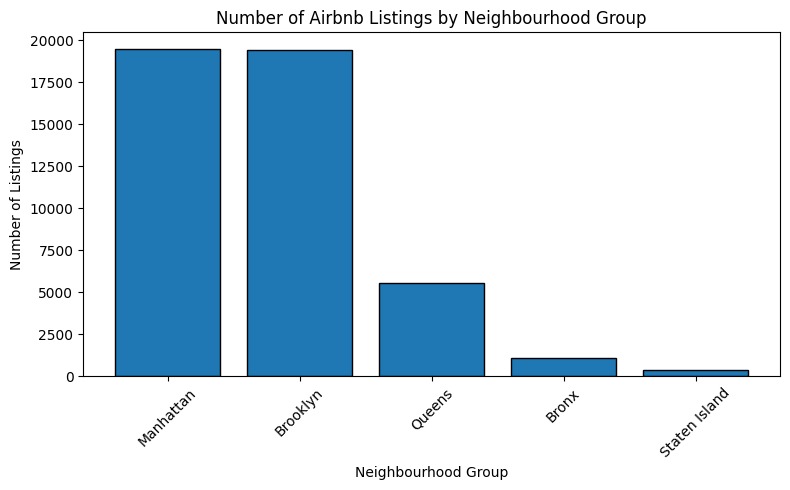

In [10]:
# Count listings by neighbourhood group

neighbourhood_counts = df["neighbourhood_group"].value_counts()

print(neighbourhood_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    neighbourhood_counts.index,
    neighbourhood_counts.values,
    edgecolor="black"
)

plt.title("Number of Airbnb Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.8.2 Average Price by Neighbourhood Group

The average Airbnb price is compared across different neighbourhood groups. This helps determine whether location has an influence on the nightly price of a listing.

neighbourhood_group
Manhattan        145.960318
Brooklyn         105.748634
Staten Island     89.235616
Queens            88.904437
Bronx             77.437792
Name: price, dtype: float64


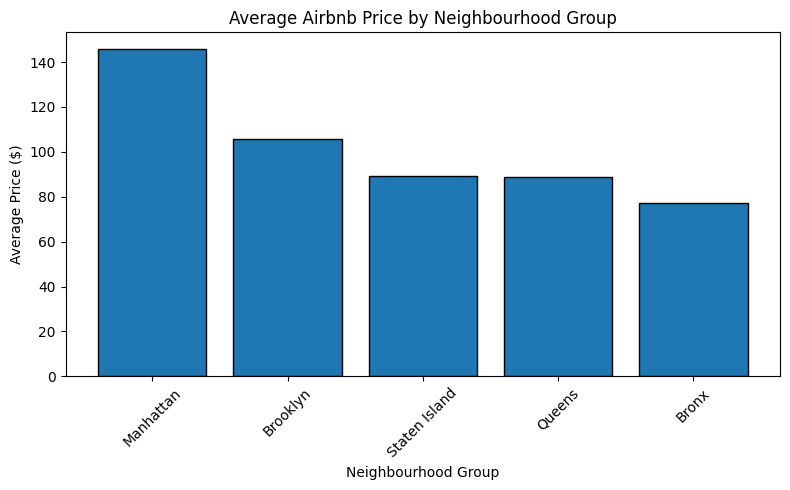

In [11]:
# Calculate average price by neighbourhood group

avg_price_neighbourhood = (
    df.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_neighbourhood)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_neighbourhood.index,
    avg_price_neighbourhood.values,
    edgecolor="black"
)

plt.title("Average Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price ($)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.8.3 Average Price by Room Type

Room type is expected to have a significant impact on Airbnb prices. The average price of each room type is compared to understand this relationship.

room_type
Entire home/apt    162.541361
Private room        79.043658
Shared room         59.397887
Name: price, dtype: float64


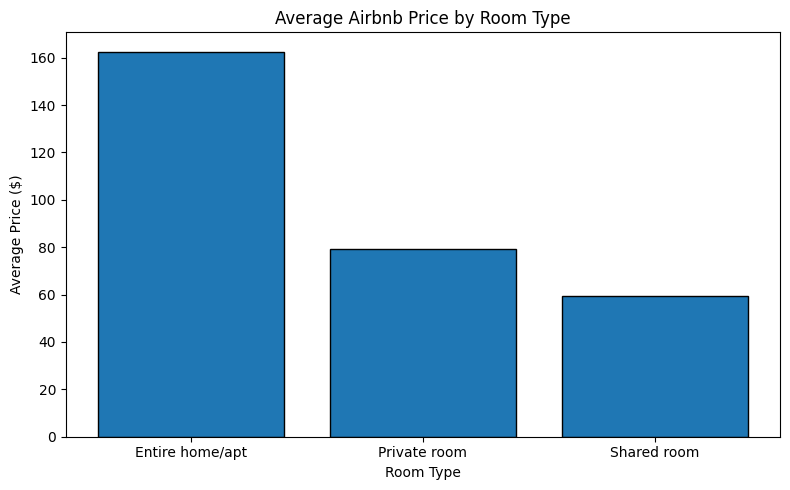

In [12]:
# Calculate average price by room type

avg_price_room = (
    df.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_room)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_room.index,
    avg_price_room.values,
    edgecolor="black"
)

plt.title("Average Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")

plt.tight_layout()
plt.show()

#### 1.8.4 Top 10 Neighbourhoods by Average Price

The average price for individual neighbourhoods is calculated to identify the neighbourhoods associated with higher Airbnb prices.

To avoid unreliable averages from neighbourhoods with very few listings, only neighbourhoods containing at least 20 listings are considered.

                    average_price  number_of_listings
neighbourhood                                        
Tribeca                212.495327                 107
NoHo                   205.290909                  55
West Village           193.118644                 649
Flatiron District      188.090909                  55
Financial District     183.973926                 652
Midtown                181.082168                1144
Greenwich Village      180.304094                 342
Murray Hill            179.981221                 426
Chelsea                178.816842                 950
Theater District       177.028807                 243


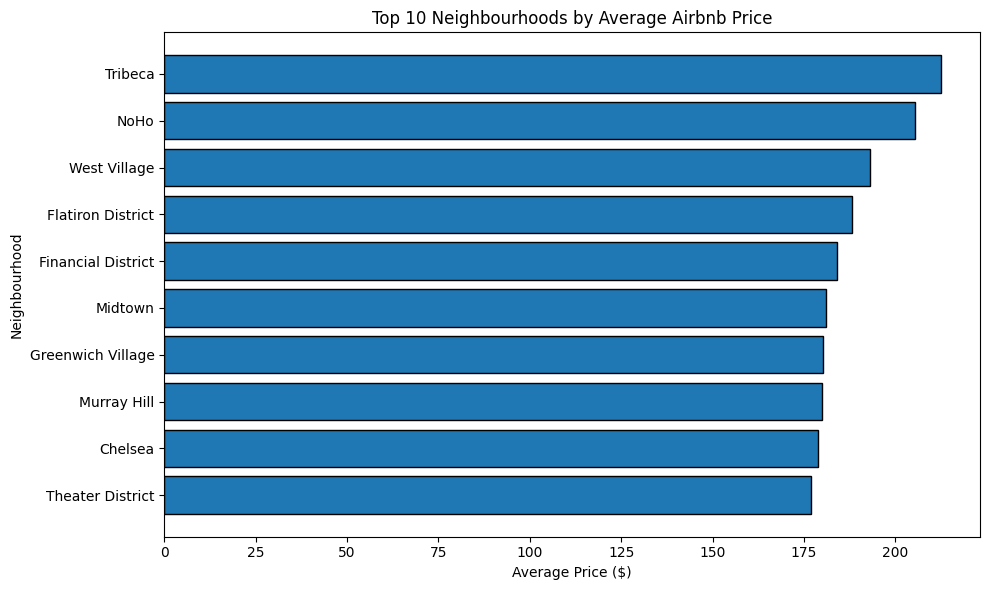

In [13]:
# Calculate neighbourhood statistics

neighbourhood_stats = df.groupby("neighbourhood").agg(
    average_price=("price", "mean"),
    number_of_listings=("price", "count")
)

# Keep neighbourhoods with at least 20 listings
neighbourhood_stats = neighbourhood_stats[
    neighbourhood_stats["number_of_listings"] >= 20
]

# Select top 10 by average price
top_10_neighbourhoods = (
    neighbourhood_stats
    .sort_values("average_price", ascending=False)
    .head(10)
)

print(top_10_neighbourhoods)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_neighbourhoods.index,
    top_10_neighbourhoods["average_price"],
    edgecolor="black"
)

plt.title("Top 10 Neighbourhoods by Average Airbnb Price")
plt.xlabel("Average Price ($)")
plt.ylabel("Neighbourhood")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 1.9 Correlation Analysis

Correlation analysis is used to examine the relationships between numerical features in the dataset. In particular, it helps identify which numerical variables have stronger positive or negative relationships with Airbnb price.

A correlation value close to +1 represents a strong positive relationship, a value close to -1 represents a strong negative relationship, and a value close to 0 represents a weak linear relationship.

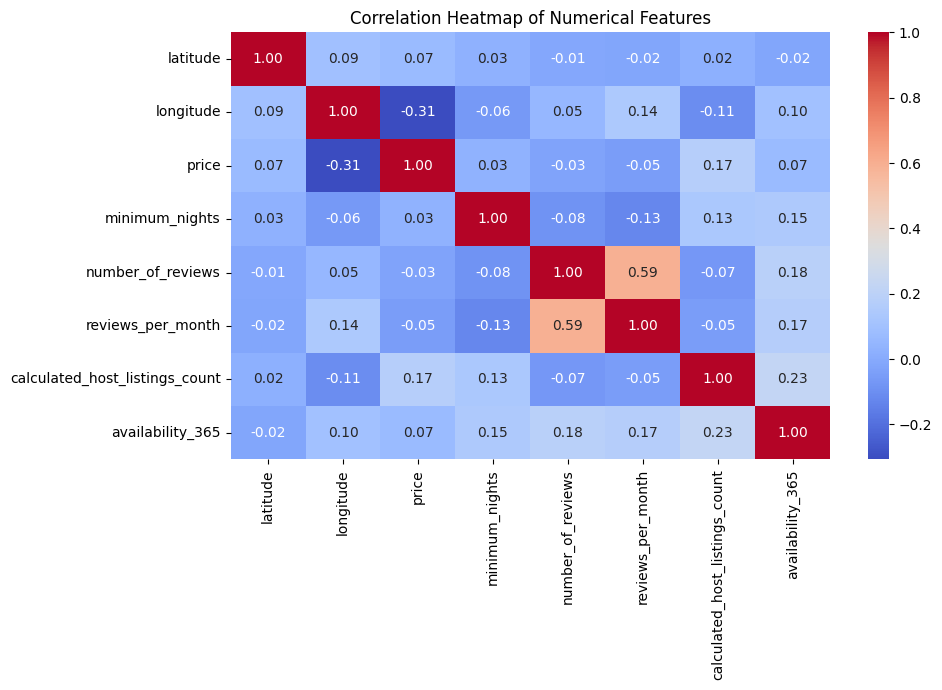

In [14]:
# Select numerical columns

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(2)


import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### 1.10 Geographic Distribution of Airbnb Listings

Latitude and longitude are used to visualize the geographical distribution of Airbnb listings across New York City. Listings are grouped by neighbourhood group to observe geographical patterns in the dataset.

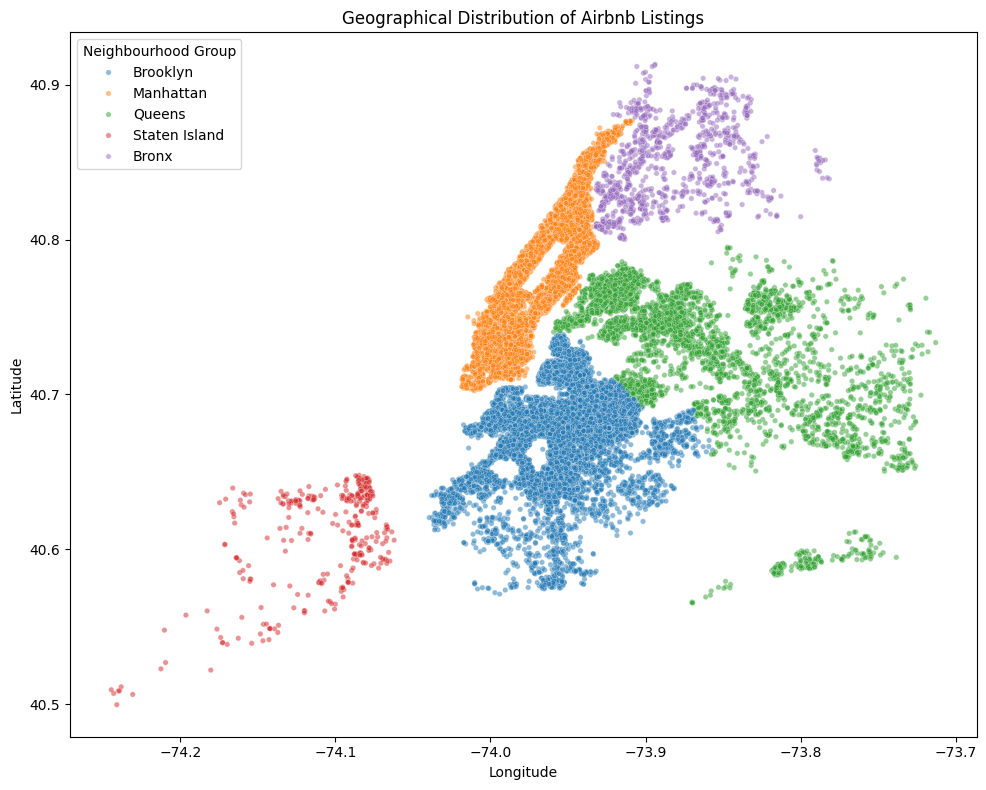

In [15]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    alpha=0.5,
    s=15
)

plt.title("Geographical Distribution of Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="Neighbourhood Group")
plt.tight_layout()
plt.show()

### 1.11 Key Findings from Exploratory Data Analysis

The exploratory analysis provides several important observations:

1. Airbnb listings are not equally distributed across the different neighbourhood groups of New York City.
2. Location has a noticeable influence on Airbnb prices, with average prices varying across neighbourhood groups.
3. Room type strongly affects price, with entire homes/apartments generally being more expensive than private and shared rooms.
4. Individual neighbourhoods also show considerable variation in average nightly prices.
5. Numerical features show different levels of correlation with price, indicating that no single numerical feature alone completely explains Airbnb pricing.
6. The geographical distribution shows that Airbnb listings are concentrated in particular areas of New York City.
7. These findings suggest that both categorical features such as location and room type, and numerical listing characteristics, should be considered when building the prediction model.

### 1.12 Feature Selection

After data cleaning and exploratory analysis, the relevant features are selected for model training.

The target variable is:

- `price` — nightly Airbnb listing price.

The predictor variables include:

- `neighbourhood_group`
- `neighbourhood`
- `latitude`
- `longitude`
- `room_type`
- `minimum_nights`
- `number_of_reviews`
- `reviews_per_month`
- `calculated_host_listings_count`
- `availability_365`

These features represent the location, room characteristics, review activity, host activity, and availability of the listing, all of which may contribute to Airbnb pricing.

In [16]:
# Define features (X) and target variable (y)

X = df.drop(columns=["price"])
y = df["price"]

print("Feature Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

print("\nSelected Features:")
print(X.columns.tolist())

Feature Dataset Shape: (45912, 10)
Target Dataset Shape: (45912,)

Selected Features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


### 1.13 Numerical and Categorical Features

The selected predictor variables contain both numerical and categorical features.

Categorical features need to be converted into numerical form before they can be used by machine learning algorithms. One-Hot Encoding will be used for categorical variables.

Numerical features will be standardized using StandardScaler so that features measured on different scales can be processed consistently.

In [17]:
# Define categorical and numerical features

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['neighbourhood_group', 'neighbourhood', 'room_type']

Numerical Features:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


### 1.14 Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.

A fixed `random_state` is used to ensure reproducibility of the results. The preprocessing pipeline will be fitted using the training data during model training to avoid data leakage.

In [18]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (36729, 10)
X_test Shape: (9183, 10)
y_train Shape: (36729,)
y_test Shape: (9183,)


### 1.15 Data Preprocessing Pipeline

A preprocessing pipeline is created using `ColumnTransformer`.

The preprocessing steps include:

- **One-Hot Encoding:** Converts categorical features such as neighbourhood group, neighbourhood, and room type into numerical representations.
- **Standardization:** StandardScaler is applied to numerical features to transform them to a comparable scale.
- **Unknown Categories:** `handle_unknown='ignore'` is used so that the pipeline can safely process categories that may not have appeared in the training data.

The preprocessing operations are kept inside the machine learning pipeline to prevent data leakage and ensure that exactly the same transformations are applied during training, testing, and future predictions.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numerical_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Task 2 - Model Training and Evaluation

Multiple regression algorithms are trained and evaluated to determine the most suitable model for Airbnb price prediction.

The following models are compared:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor

The models are evaluated using:

- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted prices.
- **MSE (Mean Squared Error):** Average squared difference between actual and predicted prices.
- **RMSE (Root Mean Squared Error):** Square root of MSE, representing prediction error in the same unit as price.
- **R² Score:** Measures how much of the variation in Airbnb prices is explained by the model.

Lower MAE, MSE, and RMSE values indicate better performance, while a higher R² score indicates better predictive performance.

In [20]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Machine learning models and evaluation metrics imported successfully.")

Machine learning models and evaluation metrics imported successfully.


### 2.2 Model Definition

Four regression algorithms are defined for comparison. Each model is combined with the same preprocessing pipeline to ensure consistent data preparation.

In [21]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

print("Models created successfully.")

Models created successfully.


### 2.3 Model Training and Comparison

Each regression model is trained using the training dataset and evaluated on the unseen testing dataset.

The same preprocessing pipeline is used for every model. Performance is compared using MAE, MSE, RMSE, and R² Score.

In [22]:
results = []

trained_models = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    # Create complete pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

    # Save trained pipeline
    trained_models[model_name] = pipeline


# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by R2 score
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,31.539394,1926.054633,43.886839,0.574643
3,Gradient Boosting,32.492754,1985.252728,44.556175,0.561570
0,Linear Regression,34.075565,2155.437670,46.426691,0.523985
1,Decision Tree,43.191332,3835.786127,61.933724,0.152891


### 2.4 Model Performance Comparison

The performance of the four regression models is compared using their RMSE and R² scores.

Random Forest achieved the best performance among the initial models, with the lowest RMSE and highest R² score. Gradient Boosting produced similar results, while the Decision Tree model performed considerably worse on the test data.

Therefore, Random Forest is selected for further evaluation and hyperparameter tuning.

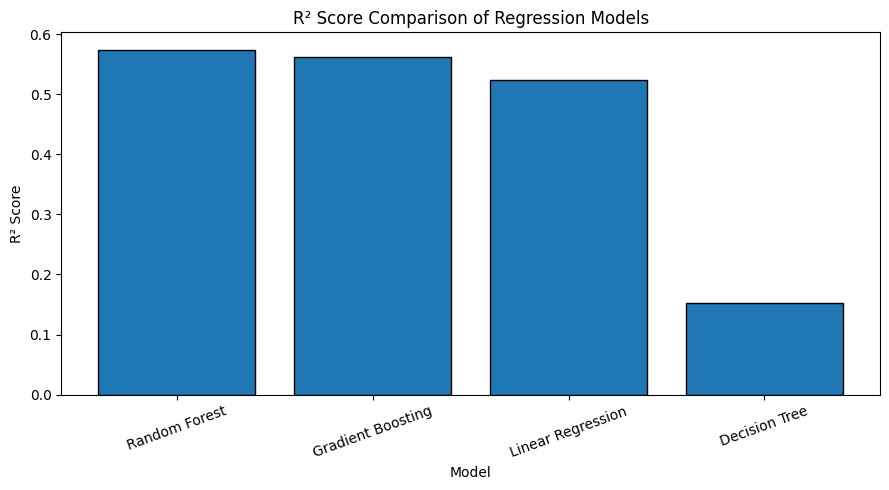

In [23]:
# Visualize R2 scores

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"],
    edgecolor="black"
)

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 2.5 Overfitting and Underfitting Analysis

Since Random Forest achieved the best initial test performance, its performance on the training and testing datasets is compared.

A model that performs extremely well on training data but significantly worse on testing data may be overfitting. Comparing the R² and RMSE values of both datasets helps identify this behaviour.

In [24]:
# Get trained Random Forest pipeline

rf_pipeline = trained_models["Random Forest"]

# Predictions
rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)

# Training metrics
train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
train_r2 = r2_score(y_train, rf_train_pred)

# Testing metrics
test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Performance")
print("-------------------------")

print("Training RMSE:", round(train_rmse, 4))
print("Testing RMSE :", round(test_rmse, 4))

print("\nTraining R²:", round(train_r2, 4))
print("Testing R² :", round(test_r2, 4))

Random Forest Performance
-------------------------
Training RMSE: 16.7252
Testing RMSE : 43.8868

Training R²: 0.9401
Testing R² : 0.5746


### 2.6 Hyperparameter Tuning of Random Forest

The initial Random Forest model may overfit the training data because individual decision trees can become very deep.

To improve generalization, hyperparameter tuning is performed using `RandomizedSearchCV` with cross-validation.

The following parameters are tuned:

- `n_estimators` — number of trees in the forest
- `max_depth` — maximum depth of each tree
- `min_samples_split` — minimum samples required to split a node
- `min_samples_leaf` — minimum samples required at a leaf node
- `max_features` — number of features considered when searching for the best split

Cross-validation is used to evaluate different combinations and identify a model that performs well on unseen data.

In [25]:
from sklearn.model_selection import RandomizedSearchCV

# Create Random Forest pipeline for tuning

rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Hyperparameter search space

param_distributions = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(round(-random_search.best_score_, 4))

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': 15}

Best Cross-Validation RMSE:
44.2097


### 2.7 Evaluation of the Tuned Random Forest Model

The best Random Forest configuration identified through hyperparameter tuning is evaluated on both the training and testing datasets.

The training and testing performance is compared to determine whether hyperparameter tuning reduces overfitting and improves the model's ability to generalize to unseen Airbnb listings.

In [26]:
# Best tuned model
best_model = random_search.best_estimator_

# Predictions
tuned_train_pred = best_model.predict(X_train)
tuned_test_pred = best_model.predict(X_test)

# Training metrics
tuned_train_mae = mean_absolute_error(y_train, tuned_train_pred)
tuned_train_rmse = np.sqrt(mean_squared_error(y_train, tuned_train_pred))
tuned_train_r2 = r2_score(y_train, tuned_train_pred)

# Testing metrics
tuned_test_mae = mean_absolute_error(y_test, tuned_test_pred)
tuned_test_mse = mean_squared_error(y_test, tuned_test_pred)
tuned_test_rmse = np.sqrt(tuned_test_mse)
tuned_test_r2 = r2_score(y_test, tuned_test_pred)

print("Tuned Random Forest Performance")
print("--------------------------------")

print("\nTraining Performance")
print("MAE :", round(tuned_train_mae, 4))
print("RMSE:", round(tuned_train_rmse, 4))
print("R²  :", round(tuned_train_r2, 4))

print("\nTesting Performance")
print("MAE :", round(tuned_test_mae, 4))
print("MSE :", round(tuned_test_mse, 4))
print("RMSE:", round(tuned_test_rmse, 4))
print("R²  :", round(tuned_test_r2, 4))

Tuned Random Forest Performance
--------------------------------

Training Performance
MAE : 24.9084
RMSE: 35.0035
R²  : 0.7376

Testing Performance
MAE : 31.1657
MSE : 1864.2867
RMSE: 43.1774
R²  : 0.5883


### 2.8 Original vs Tuned Random Forest

The original Random Forest model is compared with the hyperparameter-tuned Random Forest model.

The final model is selected by considering both predictive performance on the test dataset and the difference between training and testing performance. This helps balance prediction accuracy and model generalization.

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    
    "Test MAE": [
        mean_absolute_error(y_test, rf_test_pred),
        tuned_test_mae
    ],
    
    "Test RMSE": [
        test_rmse,
        tuned_test_rmse
    ],
    
    "Test R2": [
        test_r2,
        tuned_test_r2
    ]
})

comparison

,Model,Test MAE,Test RMSE,Test R2
0,Original Random Forest,31.539394,43.886839,0.574643
1,Tuned Random Forest,31.165737,43.177386,0.588284


### 2.9 Final Model Selection

Based on the model comparison and hyperparameter tuning results, the Tuned Random Forest Regressor is selected as the final model.

The original Random Forest achieved a test MAE of approximately 31.54, RMSE of 43.89, and R² score of 0.575. After hyperparameter tuning, the model achieved:

- **Test MAE:** 31.17
- **Test RMSE:** 43.18
- **Test R² Score:** 0.5883

The tuned model therefore performs better than the original Random Forest on all three test metrics.

The tuned model achieved a training R² score of 0.7376 and a testing R² score of 0.5883. Although some difference remains between training and testing performance, hyperparameter tuning helps control model complexity while improving performance on unseen data.

Therefore, the Tuned Random Forest is selected as the final Airbnb price prediction model.

### 2.10 Actual vs Predicted Prices

The actual Airbnb prices are compared with the prices predicted by the final model.

A prediction close to the diagonal reference line indicates that the predicted price is close to the actual price.

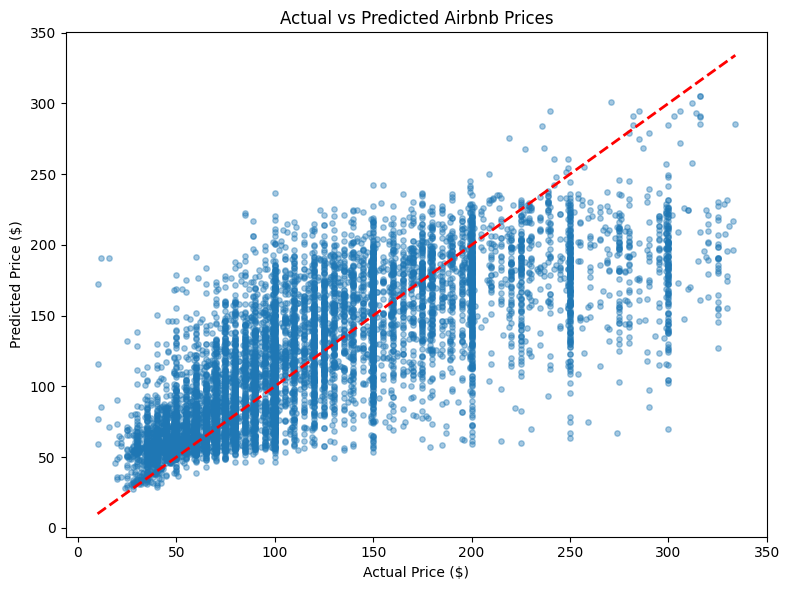

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_test_pred,
    alpha=0.4,
    s=15
)

# Perfect prediction reference line
min_price = min(y_test.min(), tuned_test_pred.min())
max_price = max(y_test.max(), tuned_test_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    "r--",
    linewidth=2
)

plt.title("Actual vs Predicted Airbnb Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")

plt.tight_layout()
plt.show()

### 2.11 Residual Analysis

Residuals represent the difference between the actual and predicted Airbnb prices.

Residual analysis helps determine whether the model makes systematic prediction errors. Ideally, residuals should be distributed around zero without a strong visible pattern.

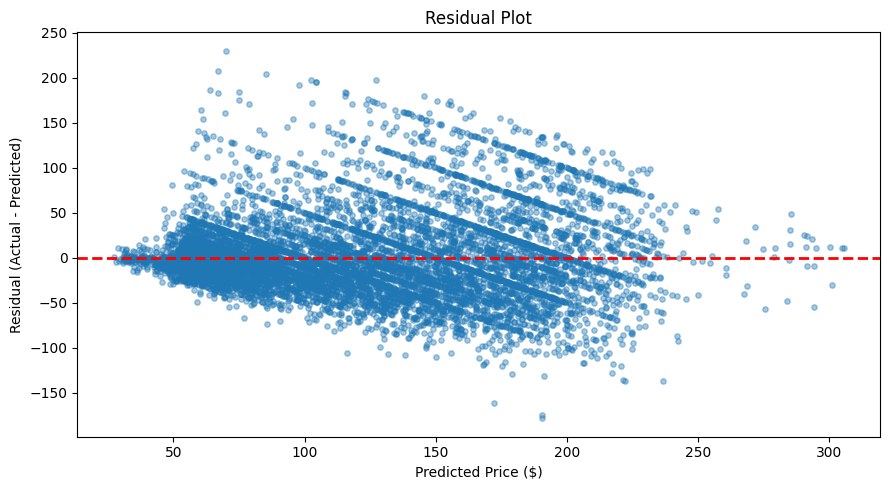

In [29]:
# Calculate residuals

residuals = y_test - tuned_test_pred

plt.figure(figsize=(9, 5))

plt.scatter(
    tuned_test_pred,
    residuals,
    alpha=0.4,
    s=15
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

### 2.12 Saving the Final Machine Learning Pipeline

The final tuned Random Forest pipeline is saved using Joblib.

The saved pipeline contains both:

- Data preprocessing operations
- Trained Random Forest regression model

Saving the complete pipeline ensures that exactly the same preprocessing transformations are applied when new Airbnb listing information is provided through the web application.

In [30]:
import joblib

# Save the complete preprocessing + model pipeline

joblib.dump(best_model, "model.pkl")

print("Final model pipeline saved successfully as model.pkl")

Final model pipeline saved successfully as model.pkl


### 2.13 Testing the Saved Pipeline

The saved model pipeline is loaded again and tested using a sample from the test dataset. This verifies that the saved model can successfully process new input data and generate price predictions.

In [31]:
# Load saved model

loaded_model = joblib.load("model.pkl")

# Select one sample listing from test data
sample_listing = X_test.iloc[[0]]

# Make prediction
sample_prediction = loaded_model.predict(sample_listing)

print("Sample Airbnb Listing:")
display(sample_listing)

print("\nActual Price: $", round(y_test.iloc[0], 2))
print("Predicted Price: $", round(sample_prediction[0], 2))

Sample Airbnb Listing:


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
35431,Manhattan,Harlem,40.80375,-73.95501,Entire home/apt,2,20,2.02,1,11



Actual Price: $ 200
Predicted Price: $ 144.2
